# > # Black–Scholes Option Pricing & Monte Carlo Engine

A practical exploration of option pricing combining analytical models, numerical methods, and market realism.

This project implements a complete derivatives pricing pipeline:

- Closed-form pricing using the Black–Scholes model  
- Sensitivity analysis via Greeks (Delta, Gamma, Vega, Theta)  
- Implied volatility extraction from market prices  
- Volatility smile analysis to capture real-world deviations  
- Monte Carlo simulation for numerical pricing  
- Variance reduction using antithetic variates for improved efficiency  

By integrating analytical and simulation-based approaches, this project highlights the trade-off between theoretical models and real market behavior.

## Black–Scholes Model

The Black–Scholes model provides a closed-form solution for pricing European options.  
The model assumes log-normal price dynamics, constant volatility, frictionless markets, and no arbitrage opportunities.

## Project Components

1. **Black–Scholes Pricing**  
   Closed-form solution for European call options  

2. **Greeks Calculation**  
   Delta, Gamma, Vega, and Theta sensitivity analysis  

3. **Implied Volatility Estimation**  
   Recovering volatility from observed market prices  

4. **Volatility Smile Simulation**  
   Demonstrating non-constant volatility across strikes  

5. **Monte Carlo Pricing**  
   Numerical option pricing via stochastic simulation  

6. **Variance Reduction (Antithetic Variates)**  
   Improving simulation efficiency and convergence  

7. **Convergence Analysis**  
   Comparing Monte Carlo estimates with analytical benchmarks  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## Black–Scholes Formula

The Black–Scholes formula for a European call option is:

\[
C = S N(d_1) - K e^{-rT} N(d_2)
\]

Where:

- \( S \): Stock price  
- \( K \): Strike price  
- \( r \): Risk-free rate  
- \( T \): Time to maturity  
- \( \sigma \): Volatility  

\[
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma \sqrt{T}}
\]

\[
d_2 = d_1 - \sigma \sqrt{T}
\]

In [ ]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

In [ ]:
S = 100   # stock price
K = 100   # strike
T = 1     # 1 year
r = 0.05  # 5% rate
sigma = 0.2  # 20% vol

price = black_scholes_call(S, K, T, r, sigma)
print(f"Call Option Price: {price:.4f}")

Call Option Price: 10.4506


## Option Price vs Stock Price

We analyze how the call option price changes with respect to the underlying stock price.

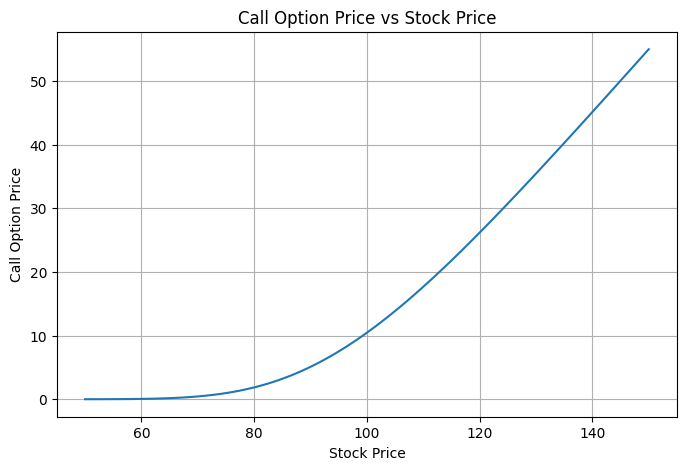

In [ ]:
S_range = np.linspace(50, 150, 100)

prices = [black_scholes_call(S, K, T, r, sigma) for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, prices)
plt.xlabel("Stock Price")
plt.ylabel("Call Option Price")
plt.title("Call Option Price vs Stock Price")
plt.grid(True)
plt.show()

## Delta of a Call Option

Delta measures the sensitivity of the option price with respect to the underlying stock price.

\[
\Delta = N(d_1)
\]

In [ ]:
def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

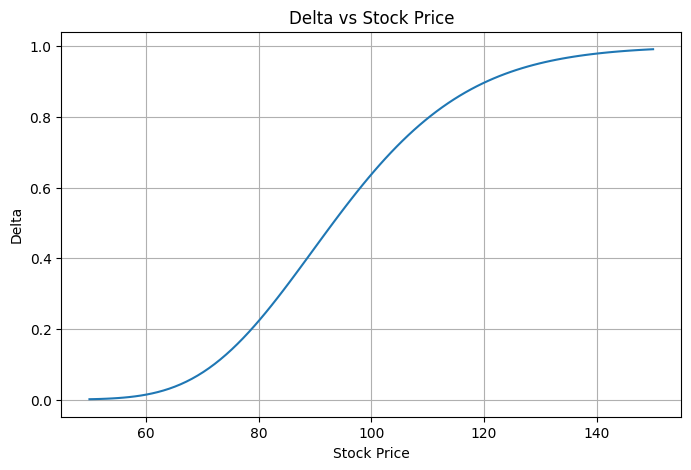

In [ ]:
deltas = [delta_call(S, K, T, r, sigma) for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, deltas)
plt.xlabel("Stock Price")
plt.ylabel("Delta")
plt.title("Delta vs Stock Price")
plt.grid(True)
plt.show()

## Gamma of a Call Option

Gamma measures the rate of change of Delta with respect to the stock price.

\[
\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}
\]

In [ ]:
def gamma_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

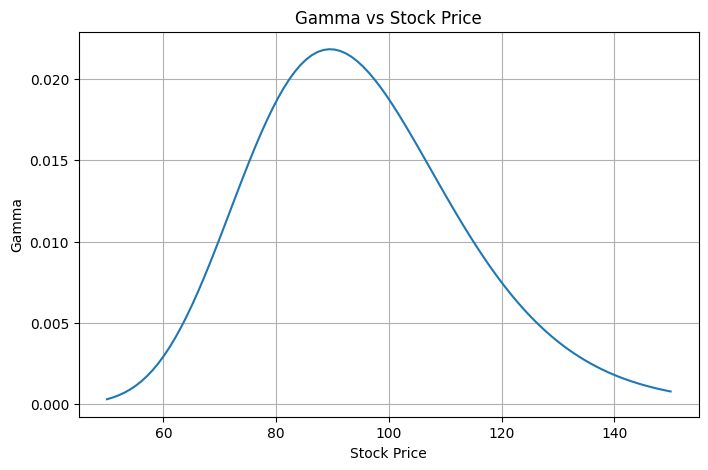

In [ ]:
gammas = [gamma_call(S, K, T, r, sigma) for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, gammas)
plt.xlabel("Stock Price")
plt.ylabel("Gamma")
plt.title("Gamma vs Stock Price")
plt.grid(True)
plt.show()

## Vega of a Call Option

Vega measures the sensitivity of the option price with respect to volatility.

\[
Vega = S N'(d_1)\sqrt{T}
\]

It is highest for at-the-money options and decreases as the option moves in- or out-of-the-money.

In [ ]:
def vega_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

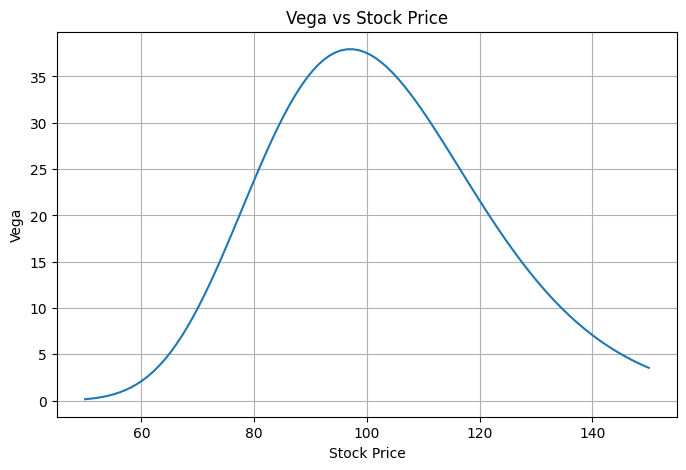

In [ ]:
vegas = [vega_call(S, K, T, r, sigma) for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, vegas)
plt.xlabel("Stock Price")
plt.ylabel("Vega")
plt.title("Vega vs Stock Price")
plt.grid(True)
plt.show()

## Theta of a Call Option

Theta measures the sensitivity of the option price with respect to time.

\[
\Theta = -\frac{S N'(d_1)\sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)
\]

Theta is typically negative for long call options, reflecting time decay.

In [ ]:
def theta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    term1 = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r * T) * norm.cdf(d2)

    return term1 + term2

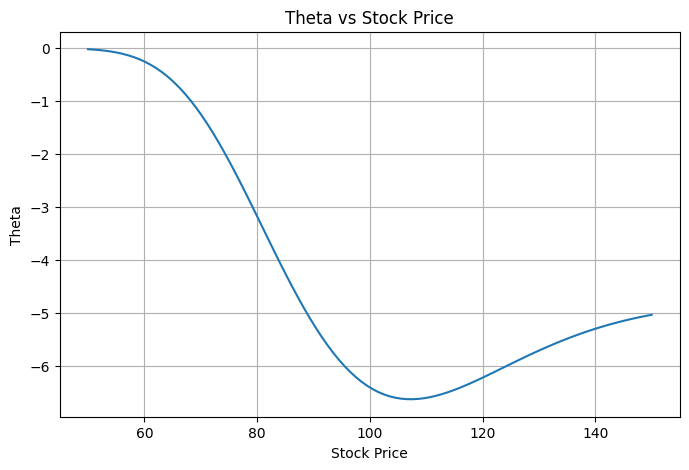

In [ ]:
thetas = [theta_call(S, K, T, r, sigma) for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, thetas)
plt.xlabel("Stock Price")
plt.ylabel("Theta")
plt.title("Theta vs Stock Price")
plt.grid(True)
plt.show()

## Summary of Results

This project implements the Black-Scholes model and analyzes option sensitivities (Greeks) to understand how option values respond to market changes.

### Greeks Interpretation

- **Delta**: Measures directional exposure to the underlying asset  
- **Gamma**: Measures convexity and rate of change of Delta  
- **Vega**: Measures sensitivity to changes in implied volatility  
- **Theta**: Measures time decay (loss of option value over time)  

---

### Key Observations

- Delta transitions smoothly from 0 → 1 as the option moves from out-of-the-money to in-the-money  
- Gamma peaks at-the-money, indicating highest convexity and hedging sensitivity  
- Vega is highest at-the-money, where uncertainty about future price movement is greatest  
- Theta is most negative at-the-money, reflecting maximum time decay  

---

### Risk Interpretation

- At-the-money options carry the **highest risk exposure** across multiple dimensions:
  - Maximum Gamma → hedging instability  
  - Maximum Vega → volatility sensitivity  
  - Maximum Theta decay → time erosion  

- Deep ITM/OTM options behave more like linear instruments with reduced sensitivity  

---

### Practical Implications

- Traders monitor Gamma and Vega closely for **risk management and hedging**
- Theta is critical for **options selling strategies**
- Understanding these dynamics is essential for:
  - Options trading
  - Volatility strategies
  - Market-making and hedging systems  

---

### Conclusion

The results align with theoretical expectations and demonstrate how option risk is concentrated around at-the-money regions, making them the most sensitive to market changes.

## Implied Volatility Estimation

Implied volatility is the volatility value that makes the Black-Scholes theoretical option price equal to the observed market option price.

Instead of pricing an option from volatility, we reverse the process:

\[
Market\ Price = BlackScholes(S, K, T, r, \sigma)
\]

The goal is to solve for:

\[
\sigma
\]

This is commonly used in derivatives trading to understand how the market prices expected future volatility.

In [ ]:
from scipy.optimize import brentq

def implied_volatility_call(market_price, S, K, T, r):
    """
    Estimate implied volatility for a European call option
    using the Black-Scholes formula.
    """
    def objective_function(sigma):
        return black_scholes_call(S, K, T, r, sigma) - market_price

    implied_vol = brentq(objective_function, 0.0001, 5.0)
    return implied_vol

In [ ]:
market_price = 10.45

iv = implied_volatility_call(market_price, S, K, T, r)

print(f"Implied Volatility: {iv:.2%}")

Implied Volatility: 20.00%


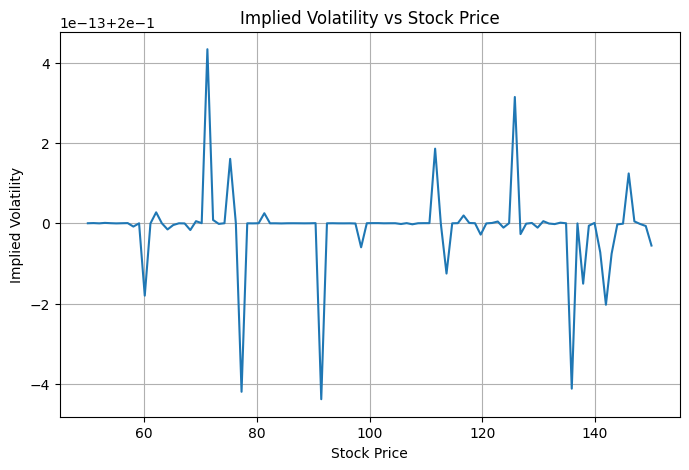

In [ ]:
market_prices = [black_scholes_call(S, K, T, r, sigma) for S in S_range]

implied_vols = [
    implied_volatility_call(price, S, K, T, r)
    for price, S in zip(market_prices, S_range)
]

plt.figure(figsize=(8,5))
plt.plot(S_range, implied_vols)
plt.title("Implied Volatility vs Stock Price")
plt.xlabel("Stock Price")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.show()

### Implied Volatility Behavior

Under the Black-Scholes model, implied volatility remains constant across different stock prices.

In practice, however, markets exhibit volatility smiles and skews, where implied volatility varies by strike and maturity.

This highlights a key limitation of the Black-Scholes model and motivates more advanced models such as stochastic volatility models.

## Volatility Smile Simulation

The Black-Scholes model assumes constant volatility.  
However, real options markets often show a volatility smile or skew, where implied volatility changes across strike prices.

This section simulates a simple volatility smile to demonstrate how market-implied volatility can vary by strike.

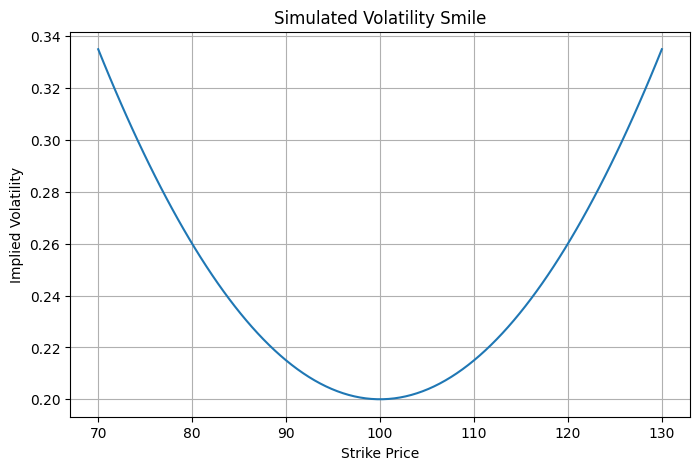

In [ ]:
K_range = np.linspace(70, 130, 100)

# Simulated volatility smile
smile_vols = 0.20 + 0.00015 * (K_range - 100)**2

plt.figure(figsize=(8,5))
plt.plot(K_range, smile_vols)
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.title("Simulated Volatility Smile")
plt.grid(True)
plt.show()

### Volatility Smile Interpretation

The simulated volatility smile shows that implied volatility is lowest near the at-the-money strike and increases for deep in-the-money and out-of-the-money options.

In real markets, this phenomenon is commonly observed and reflects several factors:

- Demand for downside protection (puts) increases implied volatility for lower strikes  
- Market participants price in tail risk and extreme events  
- Volatility is not constant and varies with strike and maturity  

---

### Model Limitation

The Black-Scholes model assumes constant volatility, which leads to a flat implied volatility surface.

However, real markets exhibit volatility smiles and skews, highlighting the need for more advanced models such as:

- Stochastic volatility models (e.g., Heston)
- Local volatility models
- Jump-diffusion models  

---

### Practical Insight

Understanding volatility smiles is critical for:

- Options trading strategies  
- Volatility arbitrage  
- Risk management and hedging  
- Pricing exotic derivatives  

This demonstrates that while Black-Scholes provides a useful foundation, it does not fully capture real-world market behavior.

## Final Takeaways

This project demonstrates the full pipeline of option analysis:

- Pricing using Black-Scholes
- Sensitivity analysis via Greeks
- Market-implied expectations via implied volatility
- Real-world deviations via volatility smile

It highlights the gap between theoretical models and actual market behavior, which is central to quantitative finance.

## Monte Carlo Convergence Analysis

Monte Carlo pricing accuracy improves as the number of simulations increases.

We compare the Monte Carlo estimate with the analytical Black-Scholes price as the number of simulations grows.

In [ ]:
def monte_carlo_call_price(S, K, T, r, sigma, num_simulations=100000):
    Z = np.random.standard_normal(num_simulations)

    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoffs = np.maximum(ST - K, 0)

    call_price = np.exp(-r * T) * np.mean(payoffs)

    return call_price

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
S = 100
K = 100
T = 1
r = 0.05
sigma = 0.20

mc_price = monte_carlo_call_price(S, K, T, r, sigma)
bs_price = black_scholes_call(S, K, T, r, sigma)

print(f"Black-Scholes Price: {bs_price:.4f}")
print(f"Monte Carlo Price: {mc_price:.4f}")
print(f"Difference: {abs(bs_price - mc_price):.4f}")

Black-Scholes Price: 10.4506
Monte Carlo Price: 10.4979
Difference: 0.0473


In [ ]:
np.random.seed(42)
simulation_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
mc_prices = []

for n in simulation_sizes:
    price = monte_carlo_call_price(S, K, T, r, sigma, num_simulations=n)
    mc_prices.append(price)

bs_price = black_scholes_call(S, K, T, r, sigma)

In [ ]:
print(mc_prices)

[np.float64(8.159991113402405), np.float64(10.399634356352596), np.float64(11.433171036167378), np.float64(10.197406362757691), np.float64(10.587512354200467), np.float64(10.48980033183451), np.float64(10.445238047430124)]


In [ ]:
len(simulation_sizes), len(mc_prices)

(7, 7)

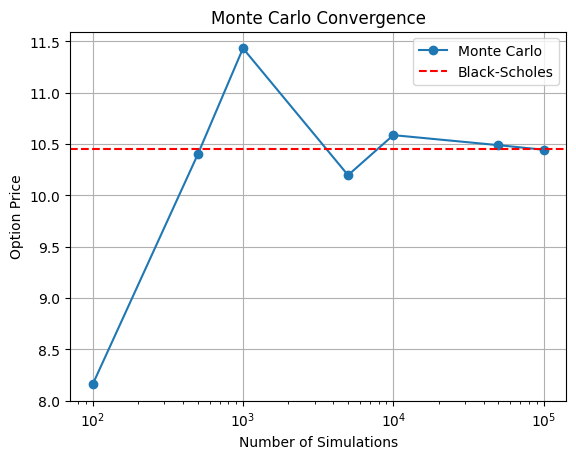

In [ ]:
plt.plot(simulation_sizes, mc_prices, marker='o', label='Monte Carlo')
plt.axhline(y=bs_price, color='r', linestyle='--', label='Black-Scholes')

plt.xlabel('Number of Simulations')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.show()

### Monte Carlo Convergence Analysis

The Monte Carlo simulation demonstrates convergence toward the analytical Black–Scholes price as the number of simulations increases.

Key observations:

- At low simulation counts, pricing estimates exhibit high variance due to randomness
- As the number of simulations increases, estimates stabilize and converge
- The Monte Carlo estimate approaches the Black–Scholes benchmark (~10.45)
- Residual noise persists even at high simulation counts, reflecting inherent stochastic sampling error

This illustrates the trade-off between computational cost and pricing accuracy in numerical methods.

In practice, Monte Carlo methods are essential for pricing complex derivatives where closed-form solutions are not available.

## Monte Carlo with Variance Reduction (Antithetic Variates)

Standard Monte Carlo simulation can exhibit high variance, especially for low simulation counts.

To improve efficiency, we use **antithetic variates**, a variance reduction technique:

- For each random draw \( Z \), we also simulate \( -Z \)
- This creates negatively correlated samples
- The estimator variance is reduced without increasing computational cost significantly

This leads to faster convergence toward the true option price.

In [ ]:
def monte_carlo_call_antithetic(S, K, T, r, sigma, num_simulations=100000):
    # Generate half the random numbers
    Z = np.random.standard_normal(num_simulations // 2)

    # Create antithetic pairs
    Z_full = np.concatenate([Z, -Z])

    # Simulate terminal prices
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_full)

    # Payoffs
    payoffs = np.maximum(ST - K, 0)

    # Discounted price
    price = np.exp(-r * T) * np.mean(payoffs)

    return price

### Comparison: Standard vs Antithetic Monte Carlo

In [ ]:
standard_prices = []
antithetic_prices = []

for n in simulation_sizes:
    standard_prices.append(monte_carlo_call_price(S, K, T, r, sigma, n))
    antithetic_prices.append(monte_carlo_call_antithetic(S, K, T, r, sigma, n))

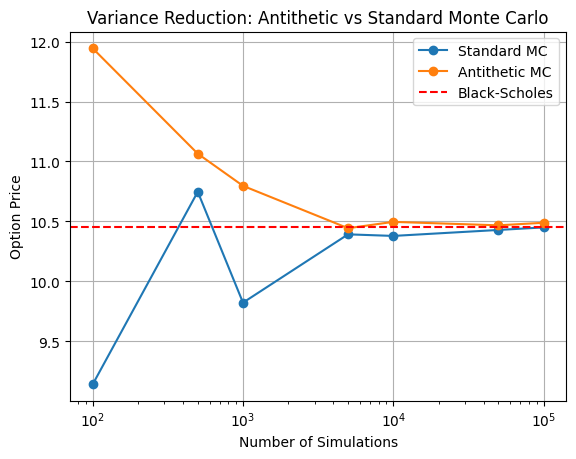

In [ ]:
plt.plot(simulation_sizes, standard_prices, marker='o', label='Standard MC')
plt.plot(simulation_sizes, antithetic_prices, marker='o', label='Antithetic MC')
plt.axhline(y=bs_price, color='r', linestyle='--', label='Black-Scholes')

plt.xscale('log')
plt.xlabel('Number of Simulations')
plt.ylabel('Option Price')
plt.title('Variance Reduction: Antithetic vs Standard Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()

### Variance Reduction: Antithetic vs Standard Monte Carlo

The plot compares the convergence behavior of standard Monte Carlo simulation and the antithetic variates method against the analytical Black–Scholes price.

#### Observations:

- The **standard Monte Carlo estimator** exhibits higher variance, particularly at lower simulation sizes, leading to unstable and noisy price estimates.

- The **antithetic variates estimator** produces significantly smoother convergence and remains closer to the Black–Scholes benchmark even with fewer simulations.

- As the number of simulations increases, both estimators converge toward the theoretical price, but the antithetic method does so more efficiently.

#### Key Insight:

Variance reduction techniques such as **antithetic variates** improve the stability and accuracy of Monte Carlo estimators without increasing computational cost.

This is critical in quantitative finance, where pricing accuracy must be balanced with computational efficiency, especially for large-scale simulations and real-time applications.

This demonstrates that smarter simulation design can outperform brute-force increases in simulation size.

## Quantitative Insights

- Monte Carlo pricing converges to the Black–Scholes analytical solution, validating the simulation framework.

- Variance reduction techniques (antithetic variates) significantly improve convergence stability without increasing computational cost.

- The volatility smile highlights a key limitation of the Black–Scholes model: real markets do not exhibit constant volatility.

- Implied volatility serves as a bridge between theoretical pricing and observed market prices.

These results reflect core challenges in quantitative finance: balancing model assumptions, numerical efficiency, and market realism.

## How to Run

1. Clone the repository
2. Install dependencies:
   pip install numpy pandas matplotlib scipy
3. Open the notebook in VS Code or Jupyter
4. Run all cells to reproduce results

In [ ]:
import time

start = time.time()
monte_carlo_call_price(S, K, T, r, sigma, num_simulations=100000)
print("Time:", time.time() - start)

Time: 0.005751132965087891
